# EDA — Dataset de Queratocono (Orbscan)

Análisis exploratorio de datos del conjunto `clinical_data_and_labels.csv`
(procedente de Zenodo, imágenes Orbscan + datos clínicos y etiquetas).

**Objetivos de este notebook**
1. Conocer la estructura y la calidad del dataset (nulos, duplicados, tipos).
2. Medir los **porcentajes de cada tipo de dato** (etiqueta, split, folds, género, ojo).
3. Entender **cómo está clasificado/particionado** el dataset (train/test + 5 folds estratificados).
4. Comparar las variables clínicas entre clases y estudiar sus correlaciones.
5. Verificar la unidad de análisis (paciente vs. ojo) y posibles fugas de información.

---

**Cómo ejecutarlo**

| Entorno | Pasos |
|---|---|
| **VS Code** | Abrir la carpeta → instalar la extensión *Jupyter* → abrir `01_EDA_queratocono.ipynb` → seleccionar el kernel de Python 3.12 → *Run All*. |
| **Google Colab** | Subir el `.ipynb` a Colab; la primera celda pedirá subir `clinical_data_and_labels.csv`. Colab ya trae pandas/numpy/matplotlib/seaborn. |
| **Local (terminal)** | `jupyter nbconvert --to notebook --execute 01_EDA_queratocono.ipynb` |

Dependencias: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `jupyter`.


In [ ]:
# Configuración general
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": False,
})

COLORES = {0: "#2E86AB", 1: "#E4572E"}   # 0 = normal, 1 = queratocono
NOMBRE = {0: "Normal (0)", 1: "Queratocono (1)"}
COLOR_BASE = "#2E86AB"

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="deep")
except ImportError:
    print("seaborn no disponible: se usará matplotlib puro.")

print("Librerías listas.")


Librerías listas.


In [ ]:
# Detección de entorno (VS Code / local) y carga de datos
def detectar_entorno():
    try:
        import google.colab  # noqa: F401
        return "colab"
    except Exception:
        return "local"


ENTORNO = detectar_entorno()
print("Entorno detectado:", ENTORNO)

if ENTORNO == "colab":
    from google.colab import files
    print("Sube el archivo clinical_data_and_labels.csv")
    subido = files.upload()
    RUTA_CSV = Path(list(subido.keys())[0])
else:
    candidatos = [
        Path("Datos/zenodo/clinical_data_and_labels.csv"),
        Path("clinical_data_and_labels.csv"),
        Path("zenodo/clinical_data_and_labels.csv"),
        Path("../Datos/zenodo/clinical_data_and_labels.csv"),
        Path(r"C:\Users\Fabricio\Desktop\desarrollo_local_PFI\Datos\zenodo\clinical_data_and_labels.csv"),
    ]
    RUTA_CSV = next((p for p in candidatos if p.exists()), None)

if RUTA_CSV is None:
    raise FileNotFoundError(
        "No se encontró clinical_data_and_labels.csv. "
        "Coloca el CSV en 'Datos/zenodo/' o súbelo al notebook."
    )

df = pd.read_csv(RUTA_CSV)
print("Ruta usada:", RUTA_CSV.resolve())
print("Dimensiones (filas, columnas):", df.shape)
df.head()


Entorno detectado: local
Ruta usada: C:\Users\Fabricio\Desktop\desarrollo_local_PFI\Datos\zenodo\clinical_data_and_labels.csv
Dimensiones (filas, columnas): (1454, 17)


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
0,63358,OS,41,m,-2.20,156,45.50,66,530,514,1.10,-0.90,-0.19,0.08,0,test,NaN
1,UAXDY,OS,30,f,-1.50,6,44.00,96,517,514,0.00,0.50,-0.29,-0.29,0,train,1.00
2,MF9GX,OD,23,m,-2.20,10,43.20,100,528,525,1.50,0.00,-0.25,2.21,0,train,2.00
3,XDKSU,OD,30,f,-2.00,28,46.50,118,541,532,-0.30,-0.50,-0.25,-0.28,0,train,5.00
4,DF14Z,OD,29,f,-2.20,139,41.60,49,544,534,-1.70,-0.50,-0.17,0.20,0,test,NaN


## Diccionario de datos

| Columna | Tipo | Descripción |
|---|---|---|
| `patient_code` | texto | Código anonimizado del paciente |
| `eye` | texto | Ojo: `OD` (derecho) u `OS` (izquierdo) |
| `age_years` | entero | Edad del paciente en años |
| `gender` | texto | `f` femenino, `m` masculino |
| `astig_value_D` | float | Astigmatismo (dioptrías) |
| `astig_axis_deg` | entero | Eje del astigmatismo (grados, 0–180, **variable circular**) |
| `kmax_value_D` | float | Queratometría máxima Kmax (dioptrías) — indicador clásico de queratocono |
| `kmax_axis_deg` | entero | Eje de Kmax (grados, **variable circular**) |
| `pachy_central_um` | entero | Paquimetría central (µm) |
| `pachy_thinnest_um` | entero | Paquimetría en el punto más delgado (µm) |
| `pachy_thinnest_x` / `_y` | float | Coordenadas del punto más delgado (mm) |
| `asphericity_anterior` | float | Asfericidad de la superficie anterior (Q) |
| `asphericity_posterior` | float | Asfericidad de la superficie posterior (Q) |
| `label` | entero | **Etiqueta de clase (variable objetivo)**: `0` = ojo normal, `1` = queratocono |
| `split_80_20` | texto | Partición `train` (80%) / `test` (20%) |
| `fold` | entero | Fold 1–5 para validación cruzada (solo en `train`; `test` queda vacío) |

> **Significado confirmado** en la documentación oficial del dataset *CornOrb* (Zenodo: 10.5281/zenodo.17127265; paper: arXiv 2603.21245): `label 0 = normal (sin queratocono)`, `label 1 = queratocono`. Las etiquetas las asignaron oftalmólogos (dos juniors con arbitraje de un senior). Se confirma en los datos: grupo 1 → Kmax 53.1 D y paquimetría 427 µm; grupo 0 → Kmax 43.7 D y paquimetría 521 µm.


## 1. Estructura y calidad de los datos


In [ ]:
print("Primeras filas:")
display(df.head(10))

print("\nÚltimas filas:")
display(df.tail(5))

print("\nTipos de dato:")
display(pd.DataFrame({"dtype": df.dtypes.astype(str),
                      "n_valores_unicos": df.nunique()}))


Primeras filas:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
0,63358,OS,41,m,-2.20,156,45.50,66,530,514,1.10,-0.90,-0.19,0.08,0,test,NaN
1,UAXDY,OS,30,f,-1.50,6,44.00,96,517,514,0.00,0.50,-0.29,-0.29,0,train,1.00
2,MF9GX,OD,23,m,-2.20,10,43.20,100,528,525,1.50,0.00,-0.25,2.21,0,train,2.00
3,XDKSU,OD,30,f,-2.00,28,46.50,118,541,532,-0.30,-0.50,-0.25,-0.28,0,train,5.00
4,DF14Z,OD,29,f,-2.20,139,41.60,49,544,534,-1.70,-0.50,-0.17,0.20,0,test,NaN
5,3CD8B,OD,28,m,-3.00,12,46.20,102,547,537,0.60,-0.90,-0.31,0.24,0,train,4.00
6,2ZU4W,OS,26,f,-2.10,175,37.40,85,524,615,-0.20,0.20,3.00,-0.29,0,train,1.00
7,ZU4X2,OS,28,f,-0.34,165,42.40,75,545,534,0.90,-1.10,-0.01,0.61,0,train,5.00
8,SXPXF,OS,30,f,-0.50,74,46.30,164,575,564,0.10,-1.00,-0.27,-0.25,0,train,1.00
9,DEHHH,OS,26,f,-1.20,8,45.90,98,517,509,1.30,-0.20,-0.09,0.24,0,train,1.00



Últimas filas:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
1449,MV958,OD,39,f,-8.20,173,73.20,83,316,253,-0.80,-0.60,-1.72,-1.84,1,train,5.00
1450,WCPXN,OS,22,m,-4.50,9,51.30,99,477,427,0.90,-0.90,-1.39,-2.14,1,test,NaN
1451,UWBAK,OS,27,f,-7.40,153,53.70,63,503,477,0.90,-0.70,-1.39,-1.24,1,train,3.00
1452,Q4MUZ,OD,31,f,-7.60,1,55.60,91,397,390,-0.10,-0.70,-1.48,-1.51,1,test,NaN
1453,V6GKQ,OD,28,f,-7.20,56,53.10,146,395,342,-1.40,-0.50,-1.48,-1.50,1,train,2.00



Tipos de dato:


,dtype,n_valores_unicos
patient_code,str,744
eye,str,2
age_years,int64,44
gender,str,2
astig_value_D,float64,140
astig_axis_deg,int64,178
kmax_value_D,float64,281
kmax_axis_deg,int64,177
pachy_central_um,int64,262
pachy_thinnest_um,int64,302


In [ ]:
# Calidad: nulos, duplicados y repetición de mediciones
calidad = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2),
    "n_unicos": df.nunique(),
})
print("Reporte de calidad por columna:")
display(calidad)

print("Filas duplicadas EXACTAS:", int(df.duplicated().sum()))

pares = df.groupby(["patient_code", "eye"]).size()
repetidos = pares[pares > 1]
print("Pares paciente-ojo con más de una medición:", len(repetidos))
print("Filas adicionales que representan:", int(repetidos.sum() - len(repetidos)))
if len(repetidos):
    print("\nEjemplo de pares repetidos (son mediciones distintas, NO duplicados exactos):")
    ej = df.merge(repetidos.rename("n").reset_index()[["patient_code", "eye"]],
                  on=["patient_code", "eye"]).sort_values(["patient_code", "eye"])
    display(ej.head(8))


Reporte de calidad por columna:


,dtype,n_nulos,%_nulos,n_unicos
patient_code,str,0,0.00,744
eye,str,0,0.00,2
age_years,int64,0,0.00,44
gender,str,0,0.00,2
astig_value_D,float64,0,0.00,140
astig_axis_deg,int64,0,0.00,178
kmax_value_D,float64,0,0.00,281
kmax_axis_deg,int64,0,0.00,177
pachy_central_um,int64,0,0.00,262
pachy_thinnest_um,int64,0,0.00,302


Filas duplicadas EXACTAS: 0
Pares paciente-ojo con más de una medición: 46
Filas adicionales que representan: 47

Ejemplo de pares repetidos (son mediciones distintas, NO duplicados exactos):


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
24,181ZN,OD,24,f,-5.90,29,48.80,119,598,534,1.40,1.80,1.58,0.93,1,test,NaN
83,181ZN,OD,24,f,-5.60,27,48.80,117,597,547,0.90,1.40,1.63,1.07,1,test,NaN
80,181ZN,OS,24,f,-7.20,154,59.00,64,316,305,0.20,0.50,-0.96,-0.98,1,test,NaN
85,181ZN,OS,24,f,-8.30,155,61.50,65,379,365,0.30,0.30,-1.11,-1.49,1,test,NaN
51,1WR3Y,OD,46,f,-4.10,162,52.70,72,405,385,-0.90,-0.80,-1.55,-1.19,1,test,NaN
79,1WR3Y,OD,46,f,-4.30,177,52.90,87,424,395,-0.70,-1.10,-1.49,-0.71,1,test,NaN
37,1WR3Y,OS,46,f,-2.90,17,47.70,107,418,382,1.10,-0.50,-0.78,-1.19,1,test,NaN
59,1WR3Y,OS,46,f,-2.70,11,47.20,101,418,383,0.80,-0.90,-0.43,-1.21,1,test,NaN


In [ ]:
# Variable 'fold': los vacíos corresponden al conjunto de prueba
print("Valores de 'fold' por split_80_20:")
print(pd.crosstab(df["split_80_20"], df["fold"].fillna("(vacío)"), margins=True))


Valores de 'fold' por split_80_20:
fold         1.00  2.00  3.00  4.00  5.00   (vacío)   All
split_80_20                                              
test            0     0     0     0     0       291   291
train         230   233   231   236   233         0  1163
All           230   233   231   236   233       291  1454


## 2. Porcentajes de cada tipo de dato

Función auxiliar que devuelve conteo y porcentaje para cualquier columna categórica.


In [ ]:
def porcentajes(col, data=None):
    """Tabla de conteos + porcentaje para una columna categórica."""
    data = df if data is None else data
    s = data[col] if col != "fold" else data[col].fillna("sin fold (test)")
    t = s.value_counts(dropna=False).rename_axis(str(col)).to_frame("n")
    t["%"] = (100 * t["n"] / t["n"].sum()).round(2)
    return t


def barras_pct(tabla, titulo, ax=None, color=COLOR_BASE):
    ax = ax if ax is not None else plt.gca()
    b = ax.bar(tabla.index.astype(str), tabla["%"], color=color)
    ax.bar_label(b, labels=[f"{v:.1f}%" for v in tabla["%"]], padding=3, fontsize=10)
    ax.set_title(titulo, fontweight="bold")
    ax.set_ylabel("%")
    ax.set_ylim(0, max(tabla["%"]) * 1.18)
    return ax


### 2.1 Variable objetivo: `label`


,n,%
Normal (0),889,61.14
Queratocono (1),565,38.86


Desbalance de clases (razón 0/1): 1.57 : 1


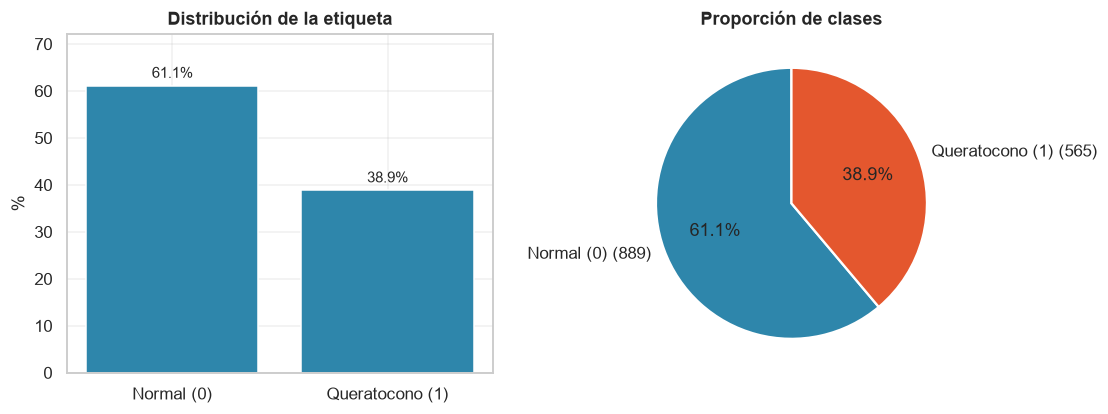

In [ ]:
t_label = porcentajes("label")
t_label.index = [NOMBRE[i] for i in t_label.index]
display(t_label)

print(f"Desbalance de clases (razón 0/1): {t_label['n'].iloc[0] / t_label['n'].iloc[1]:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
barras_pct(t_label, "Distribución de la etiqueta", ax=axes[0])
axes[1].pie(t_label["n"], labels=[f"{i} ({n:,})" for i, n in zip(t_label.index, t_label["n"])],
            autopct="%1.1f%%", startangle=90, colors=[COLORES[0], COLORES[1]],
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Proporción de clases", fontweight="bold")
plt.show()


### 2.2 Partición del dataset: `split_80_20`


,n,%
split_80_20,,
train,1163,79.99
test,291,20.01



Etiqueta repartida dentro de cada split (¿estratificación?):


split_80_20,test,train,All
label,,,
0,178,711,889
1,113,452,565
All,291,1163,1454


split_80_20,test,train
label,,
0,61.17,61.13
1,38.83,38.87


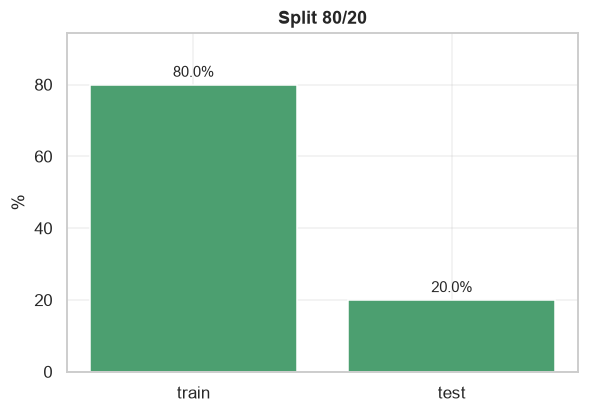

In [ ]:
t_split = porcentajes("split_80_20")
display(t_split)

print("\nEtiqueta repartida dentro de cada split (¿estratificación?):")
ct_n = pd.crosstab(df["label"], df["split_80_20"], margins=True)
ct_p = (pd.crosstab(df["label"], df["split_80_20"], normalize="columns") * 100).round(2)
display(ct_n)
display(ct_p)

fig, ax = plt.subplots(figsize=(6, 4))
barras_pct(t_split, "Split 80/20", ax=ax, color="#4C9F70")
plt.show()


### 2.3 Validación cruzada: `fold` (solo entrenamiento)


,n,%
fold,,
sin fold (test),291,20.01
4.00,236,16.23
2.00,233,16.02
5.00,233,16.02
3.00,231,15.89
1.00,230,15.82


Cobertura: los folds existen únicamente para las filas de train; el 20% de prueba no tiene fold asignado.


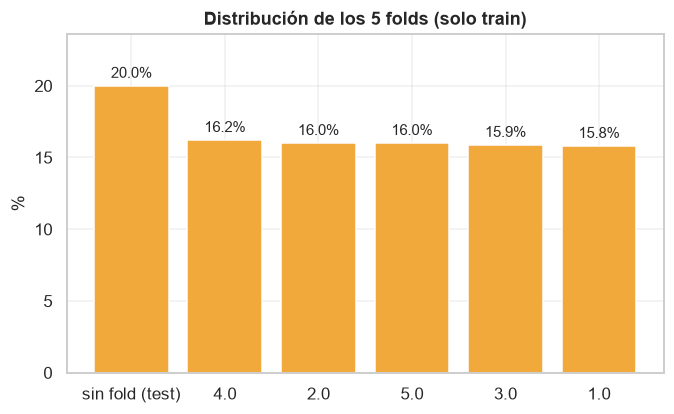

In [ ]:
t_fold = porcentajes("fold")
display(t_fold)

print("Cobertura: los folds existen únicamente para las filas de train; "
      "el 20% de prueba no tiene fold asignado.")

fig, ax = plt.subplots(figsize=(7, 4))
barras_pct(t_fold, "Distribución de los 5 folds (solo train)", ax=ax, color="#F2A93B")
plt.show()


### 2.4 Variables demográficas: género y ojo


,n,%
gender,,
Femenino,947,65.13
Masculino,507,34.87


,n,%
eye,,
Ojo derecho (OD),730,50.21
Ojo izquierdo (OS),724,49.79


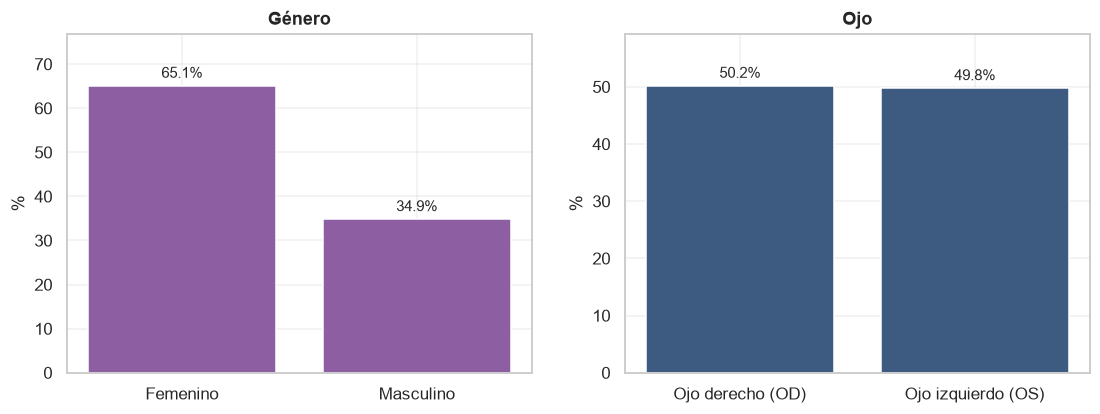


Género por clase:


label,0,1
gender,,
f,63.10,68.32
m,36.90,31.68



Ojo por clase:


label,0,1
eye,,
OD,50.06,50.44
OS,49.94,49.56


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_gender = porcentajes("gender")
t_gender.index = t_gender.index.map({"f": "Femenino", "m": "Masculino"})
display(t_gender)
barras_pct(t_gender, "Género", ax=axes[0], color="#8E5EA2")

t_eye = porcentajes("eye")
t_eye.index = t_eye.index.map({"OD": "Ojo derecho (OD)", "OS": "Ojo izquierdo (OS)"})
display(t_eye)
barras_pct(t_eye, "Ojo", ax=axes[1], color="#3D5A80")

plt.show()

print("\nGénero por clase:")
display((pd.crosstab(df["gender"], df["label"], normalize="columns") * 100).round(2))

print("\nOjo por clase:")
display((pd.crosstab(df["eye"], df["label"], normalize="columns") * 100).round(2))


In [ ]:
# Cruce completo de las tres variables de clasificación
print("label x split (conteo):")
display(pd.crosstab(df["label"], df["split_80_20"], margins=True))

print("label x género x ojo (porcentajes sobre el total):")
ct = pd.crosstab([df["gender"], df["eye"]], df["label"], margins=True)
display((ct / len(df) * 100).round(2))


label x split (conteo):


split_80_20,test,train,All
label,,,
0,178,711,889
1,113,452,565
All,291,1163,1454


label x género x ojo (porcentajes sobre el total):


label          0     1    All
gender eye                   
f      OD  19.39 13.41  32.81
       OS  19.19 13.14  32.32
m      OD  11.21  6.19  17.40
       OS  11.35  6.12  17.47
All        61.14 38.86 100.00

## 3. Unidad de análisis: paciente vs. ojo

El dataset tiene **más registros que pacientes** (un paciente puede aportar 1 o 2 ojos). Esto es clave para no cometer fugas de información entre train y test.


In [ ]:
n_pac = df["patient_code"].nunique()
print(f"Pacientes únicos: {n_pac:,}")
print(f"Registros (ojo-muestra): {len(df):,}")
print(f"Promedio de registros por paciente: {len(df)/n_pac:.2f}")

print("\nDistribución de registros por paciente:")
display(df.groupby("patient_code").size().value_counts().sort_index().rename("n_pacientes").to_frame().T)

print("\nEtiqueta a nivel de PACIENTE (constante dentro de cada paciente):")
t_pac_label = porcentajes("label", data=df.drop_duplicates("patient_code"))
t_pac_label.index = [NOMBRE[i] for i in t_pac_label.index]
display(t_pac_label)

resumen = df.groupby("patient_code").agg(
    n_registros=("eye", "size"),
    n_labels=("label", "nunique"),
    n_splits=("split_80_20", "nunique"),
)
print("\n>>> Pacientes con etiqueta mixta (debería ser 0):", int((resumen["n_labels"] > 1).sum()))
print(">>> Pacientes presentes en train Y test a la vez (fuga; debe ser 0):",
      int((resumen["n_splits"] > 1).sum()))


Pacientes únicos: 744
Registros (ojo-muestra): 1,454
Promedio de registros por paciente: 1.95

Distribución de registros por paciente:


,1,2,3,4,5
n_pacientes,74,646,9,14,1



Etiqueta a nivel de PACIENTE (constante dentro de cada paciente):


,n,%
Normal (0),446,59.95
Queratocono (1),298,40.05



>>> Pacientes con etiqueta mixta (debería ser 0): 0
>>> Pacientes presentes en train Y test a la vez (fuga; debe ser 0): 0


## 4. Variables clínicas — descripción general


In [ ]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age_years,"1,454.00",31.33,7.80,13.00,26.00,30.00,36.00,65.00
astig_value_D,"1,454.00",-2.89,2.92,-20.80,-4.07,-1.90,-1.00,12.20
astig_axis_deg,"1,454.00",91.59,66.66,1.00,22.00,90.00,162.00,180.00
kmax_value_D,"1,454.00",47.36,6.66,4.00,43.50,45.40,49.68,79.30
kmax_axis_deg,"1,454.00",91.99,35.70,1.00,72.00,91.00,112.00,180.00
pachy_central_um,"1,454.00",504.88,57.26,291.00,472.00,513.00,546.00,775.00
pachy_thinnest_um,"1,454.00",484.45,67.93,251.00,444.25,498.00,536.00,627.00
pachy_thinnest_x,"1,454.00",0.14,0.89,-2.50,-0.50,0.20,0.90,2.50
pachy_thinnest_y,"1,454.00",-0.56,0.58,-2.50,-0.90,-0.60,-0.20,2.50
asphericity_anterior,"1,454.00",-0.56,0.80,-3.79,-0.99,-0.31,-0.17,3.37


In [ ]:
# Estadísticos separados por clase
vars_clin = ["age_years", "astig_value_D", "kmax_value_D",
             "pachy_central_um", "pachy_thinnest_um",
             "asphericity_anterior", "asphericity_posterior"]

desc = df.groupby("label")[vars_clin].agg(["mean", "std", "median", "min", "max"])
display(desc.T)

print("\nDiferencia de medias (label 1 - label 0):")
medias = df.groupby("label")[vars_clin].mean()
display((medias.loc[1] - medias.loc[0]).round(2).to_frame("Δ media"))


label                             0      1
age_years             mean    33.54  27.86
                      std      7.39   7.15
                      median  32.00  27.00
                      min     17.00  13.00
                      max     59.00  65.00
astig_value_D         mean    -1.35  -5.32
                      std      0.91   3.32
                      median  -1.20  -5.00
                      min     -6.10 -20.80
                      max      3.10  12.20
kmax_value_D          mean    43.70  53.10
                      std      2.86   6.87
                      median  43.90  52.10
                      min      4.00   4.90
                      max     49.30  79.30
pachy_central_um      mean   530.39 464.72
                      std     42.92  53.88
                      median 535.00 471.00
                      min    307.00 291.00
                      max    633.00 775.00
pachy_thinnest_um     mean   520.65 427.50
                      std     44.17  59.17
                      median 526.00 437.00
                      min    273.00 251.00
                      max    627.00 589.00
asphericity_anterior  mean    -0.15  -1.20
                      std      0.45   0.81
                      median  -0.23  -1.24
                      min     -2.24  -3.79
                      max      3.00   3.37
asphericity_posterior mean    -0.17  -1.16
                      std      0.43   0.83
                      median  -0.16  -1.27
                      min     -1.94  -4.23
                      max      2.21   4.49


Diferencia de medias (label 1 - label 0):


,Δ media
age_years,-5.68
astig_value_D,-3.98
kmax_value_D,9.40
pachy_central_um,-65.67
pachy_thinnest_um,-93.16
asphericity_anterior,-1.05
asphericity_posterior,-0.99


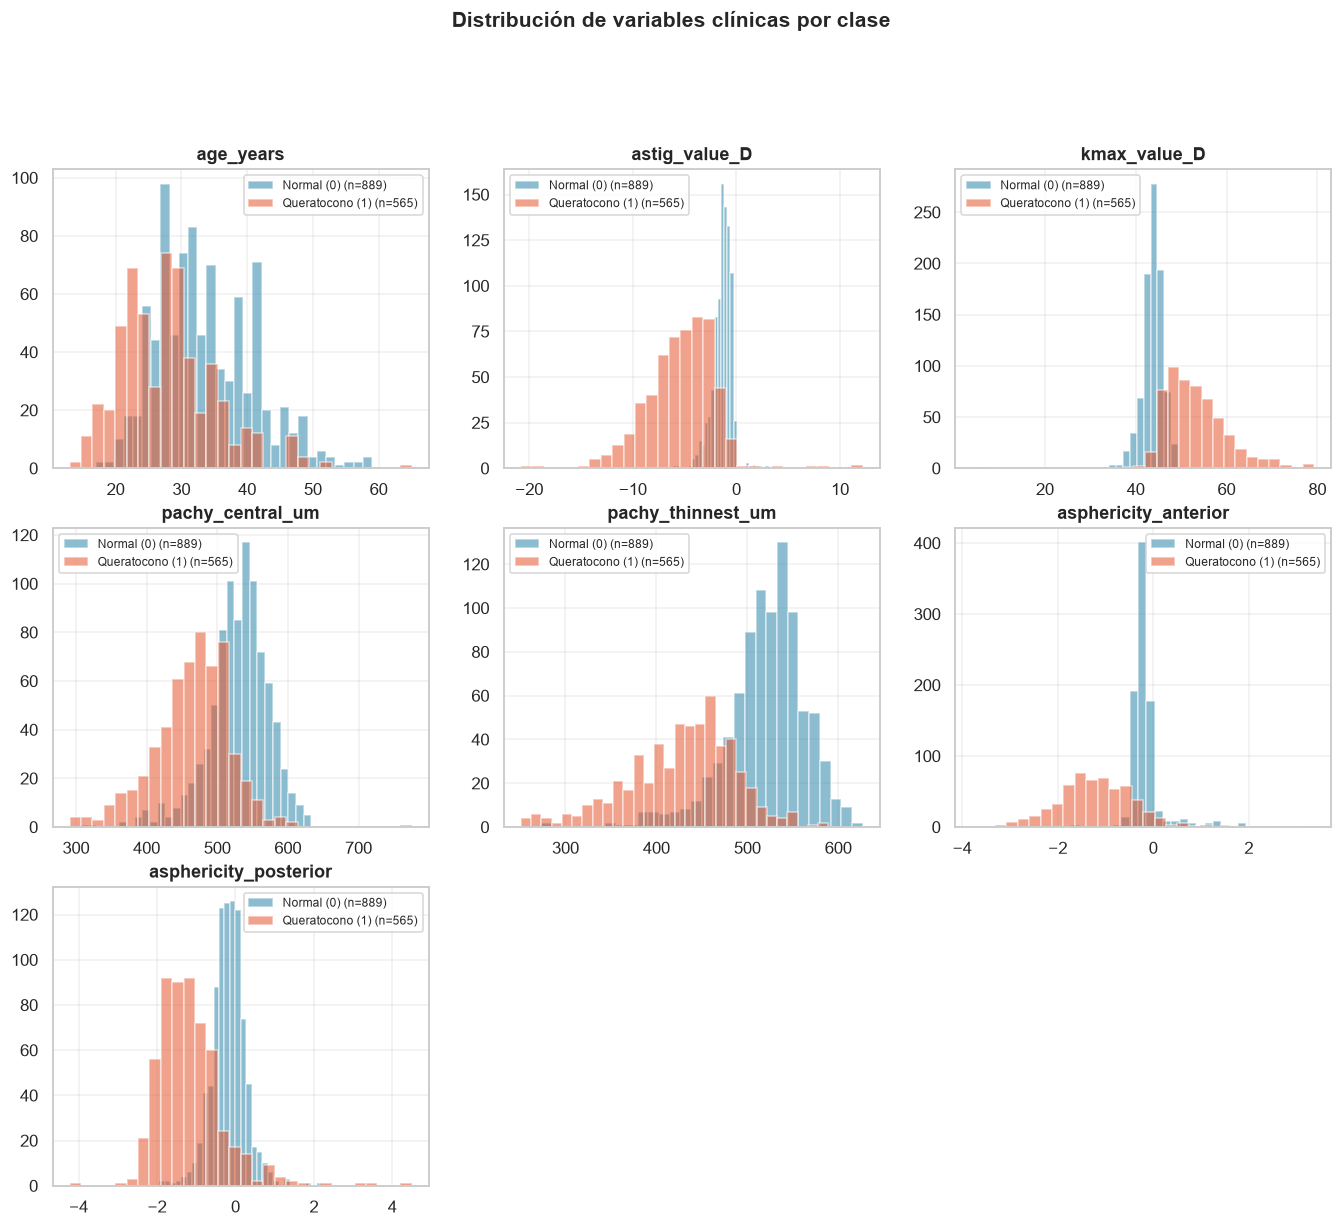

In [ ]:
# Histogramas superpuestos por clase
n_cols = 3
n_rows = int(np.ceil(len(vars_clin) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, col in zip(axes, vars_clin):
    for lab in sorted(df["label"].unique()):
        sub = df.loc[df["label"] == lab, col]
        ax.hist(sub, bins=30, alpha=0.55, color=COLORES[lab],
                label=f"{NOMBRE[lab]} (n={len(sub):,})", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8)

for ax in axes[len(vars_clin):]:
    ax.axis("off")

fig.suptitle("Distribución de variables clínicas por clase", fontsize=14, fontweight="bold", y=1.0)
plt.show()


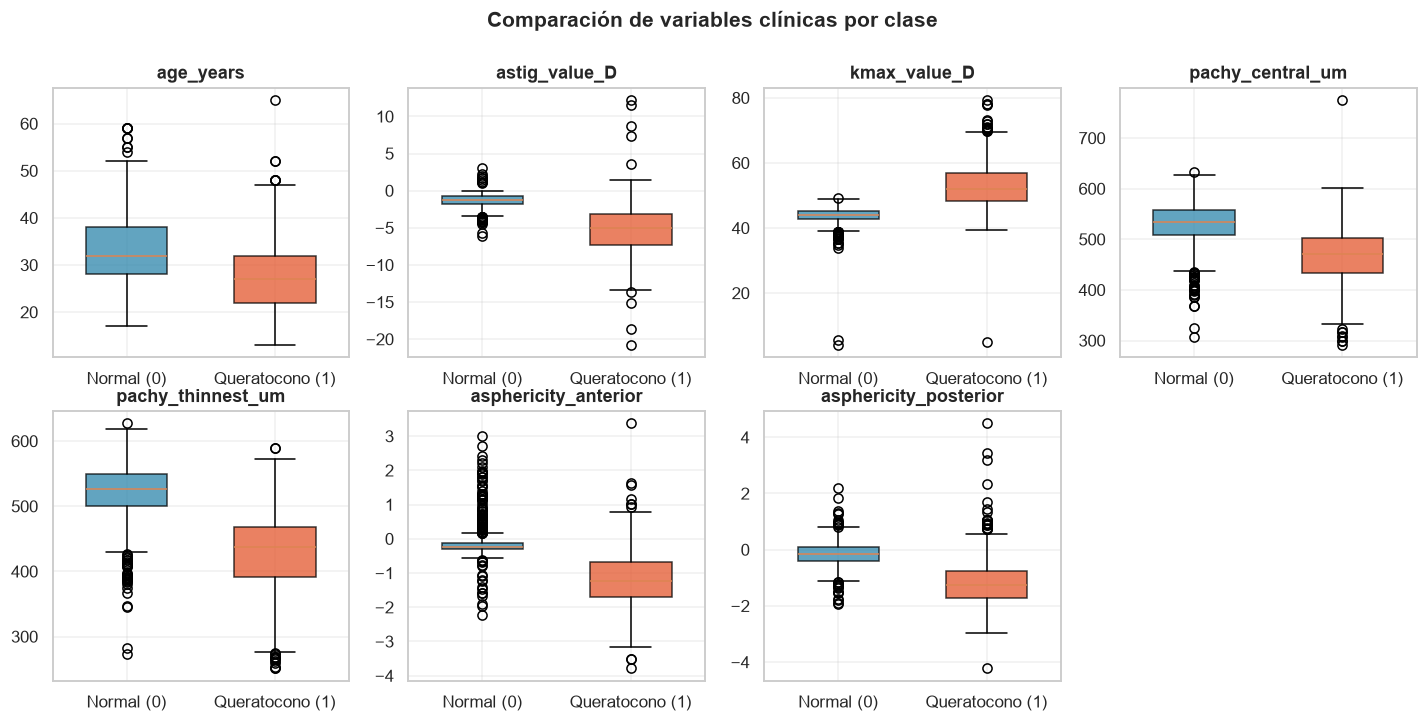

In [ ]:
# Boxplots por clase
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for ax, col in zip(axes, vars_clin):
    dados = [df.loc[df["label"] == lab, col] for lab in sorted(df["label"].unique())]
    bp = ax.boxplot(dados, tick_labels=[NOMBRE[l] for l in sorted(df["label"].unique())],
                    patch_artist=True, widths=0.55)
    for patch, lab in zip(bp["boxes"], sorted(df["label"].unique())):
        patch.set_facecolor(COLORES[lab])
        patch.set_alpha(0.75)
    ax.set_title(col, fontweight="bold")

axes[-1].axis("off")
fig.suptitle("Comparación de variables clínicas por clase", fontsize=14, fontweight="bold")
plt.show()


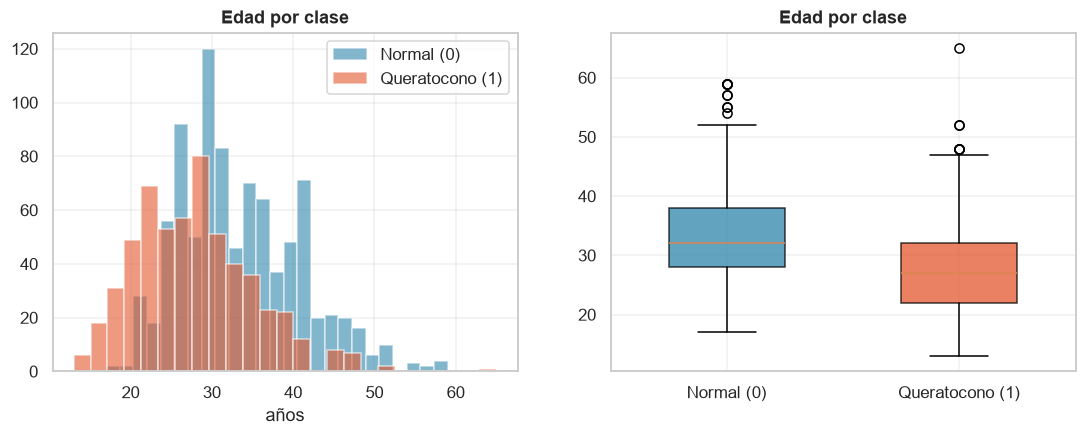

Estadísticos de edad por clase:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,889.00,33.54,7.39,17.00,28.00,32.00,38.00,59.00
1,565.00,27.86,7.15,13.00,22.00,27.00,32.00,65.00


In [ ]:
# Edad por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lab in sorted(df["label"].unique()):
    axes[0].hist(df.loc[df["label"] == lab, "age_years"], bins=25, alpha=0.6,
                 color=COLORES[lab], label=NOMBRE[lab], edgecolor="white")
axes[0].set_title("Edad por clase", fontweight="bold")
axes[0].set_xlabel("años")
axes[0].legend()

bp = axes[1].boxplot([df.loc[df["label"] == lab, "age_years"] for lab in sorted(df["label"].unique())],
                     tick_labels=[NOMBRE[l] for l in sorted(df["label"].unique())],
                     patch_artist=True, widths=0.5)
for patch, lab in zip(bp["boxes"], sorted(df["label"].unique())):
    patch.set_facecolor(COLORES[lab]); patch.set_alpha(0.75)
axes[1].set_title("Edad por clase", fontweight="bold")

plt.show()

print("Estadísticos de edad por clase:")
display(df.groupby("label")["age_years"].describe())


> `astig_axis_deg` y `kmax_axis_deg` son **variables circulares** (grados 0–180); sus histogramas y medias clásicas no son interpretables y por eso se excluyen del bloque anterior. En modelado conviene codificarlas con `sin`/`cos`.


## 5. Correlaciones

1. Matriz de correlación de Pearson entre todas las variables numéricas.
2. **Tabla rankeada** de las variables por su correlación **absoluta** con la etiqueta (`|r|`), que es con la que importa predecir; el signo indica la dirección de la relación.


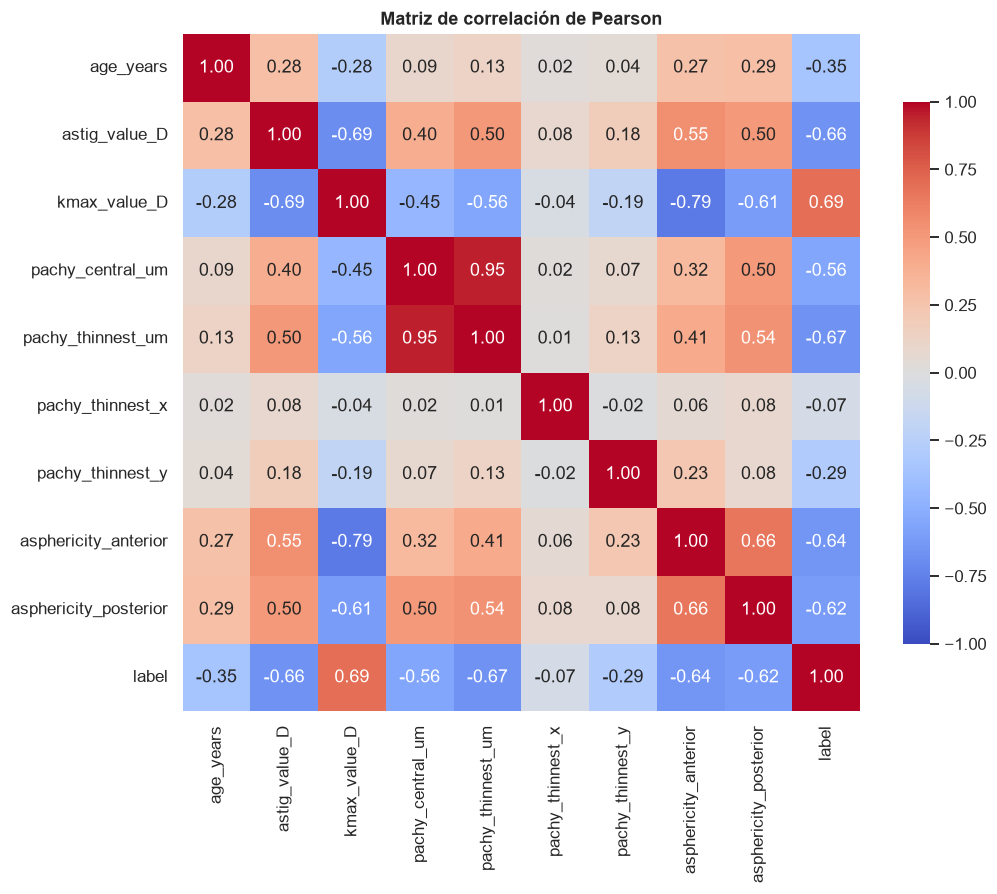

In [ ]:
num_cols = ["age_years", "astig_value_D", "kmax_value_D", "pachy_central_um",
            "pachy_thinnest_um", "pachy_thinnest_x", "pachy_thinnest_y",
            "asphericity_anterior", "asphericity_posterior", "label"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación de Pearson", fontweight="bold")
plt.show()


Ranking de variables por |r| con la etiqueta (n = 1454):


,rango,r,|r|,dirección
kmax_value_D,1,0.69,0.69,positiva
pachy_thinnest_um,2,-0.67,0.67,negativa
astig_value_D,3,-0.66,0.66,negativa
asphericity_anterior,4,-0.64,0.64,negativa
asphericity_posterior,5,-0.62,0.62,negativa
pachy_central_um,6,-0.56,0.56,negativa
age_years,7,-0.35,0.35,negativa
pachy_thinnest_y,8,-0.29,0.29,negativa
pachy_thinnest_x,9,-0.07,0.07,negativa


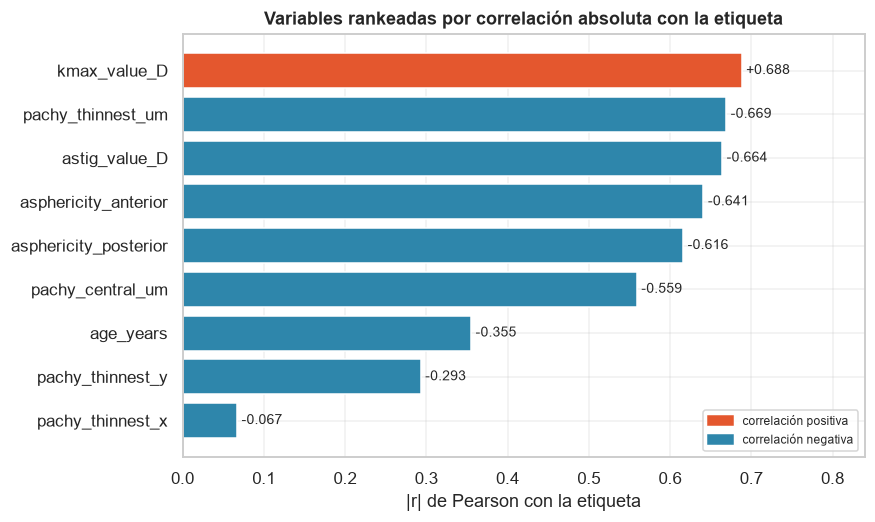

Top 3: kmax_value_D > pachy_thinnest_um > astig_value_D


In [ ]:
# Tabla rankeada por correlación ABSOLUTA con la etiqueta
tabla_corr = corr["label"].drop("label").rename("r").to_frame()
tabla_corr["|r|"] = tabla_corr["r"].abs()
tabla_corr = tabla_corr.sort_values("|r|", ascending=False)
tabla_corr.insert(0, "rango", range(1, len(tabla_corr) + 1))
tabla_corr.insert(2, "dirección", np.where(tabla_corr["r"] >= 0, "positiva", "negativa"))
tabla_corr = tabla_corr[["rango", "r", "|r|", "dirección"]]
tabla_corr[["r", "|r|"]] = tabla_corr[["r", "|r|"]].round(3)

print(f"Ranking de variables por |r| con la etiqueta (n = {len(df)}):")
display(tabla_corr)

fig, ax = plt.subplots(figsize=(8, 5))
orden = tabla_corr.iloc[::-1]
colores = ["#2E86AB" if v < 0 else "#E4572E" for v in orden["r"]]
b = ax.barh(orden.index, orden["|r|"], color=colores)
ax.bar_label(b, labels=[f"{v:+.3f}" for v in orden["r"]], padding=3, fontsize=9)
ax.set_xlabel("|r| de Pearson con la etiqueta")
ax.set_xlim(0, orden["|r|"].max() * 1.22)
ax.set_title("Variables rankeadas por correlación absoluta con la etiqueta", fontweight="bold")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#E4572E"),
                   plt.Rectangle((0, 0), 1, 1, color="#2E86AB")],
          labels=["correlación positiva", "correlación negativa"], fontsize=8, loc="lower right")
plt.show()

print("Top 3:", " > ".join(tabla_corr.index[:3]))


## 6. Inventario de imágenes Orbscan (opcional)

Solo se ejecuta si la carpeta `ORBSCAN_Dataset` está disponible. En Colab puedes subir el zip y descomprimirlo.


In [ ]:
raiz = next((p for p in [Path("Datos/zenodo/ORBSCAN_Dataset"),
                         Path("ORBSCAN_Dataset"),
                         Path("Datos/ORBSCAN_Dataset")] if p.exists()), None)

if raiz is None:
    print("Carpeta ORBSCAN_Dataset no encontrada -> se omite el inventario de imágenes.")
else:
    from collections import Counter
    ojos_disk, mapas = set(), Counter()
    n_png = 0
    for paciente in sorted(p for p in raiz.iterdir() if p.is_dir()):
        for ojo_dir in sorted(p for p in paciente.iterdir() if p.is_dir()):
            ojos_disk.add((paciente.name, ojo_dir.name))
            for img in ojo_dir.glob("*.png"):
                n_png += 1
                mapas["_".join(img.stem.split("_")[2:])] += 1

    ojos_csv = set(zip(df["patient_code"], df["eye"]))

    print(f"Pacientes con carpeta:      {len([p for p in raiz.iterdir() if p.is_dir()]):,}")
    print(f"Ojos (carpetas) en disco:   {len(ojos_disk):,}")
    print(f"Ojos en el CSV:             {len(ojos_csv):,} ({df.drop_duplicates(['patient_code','eye']).shape[0]:,} pares únicos)")
    print(f"Imágenes PNG totales:       {n_png:,}")
    print("\nImágenes por tipo de mapa:")
    display(pd.DataFrame({"n": pd.Series(mapas),
                          "%": (100 * pd.Series(mapas) / sum(mapas.values())).round(2)}))

    faltan = sorted(ojos_csv - ojos_disk)
    sobran = sorted(ojos_disk - ojos_csv)
    print(f"\nOjos en CSV sin carpeta ({len(faltan)}):", faltan[:10])
    print(f"Carpetas sin fila en CSV ({len(sobran)}):", sobran[:10])


Pacientes con carpeta:      744
Ojos (carpetas) en disco:   1,407
Ojos en el CSV:             1,407 (1,407 pares únicos)
Imágenes PNG totales:       5,628

Imágenes por tipo de mapa:


,n,%
Anterior,1407,25.00
Axial,1407,25.00
Pachymetry,1407,25.00
Posterior,1407,25.00



Ojos en CSV sin carpeta (2): [('3E+132', 'OD'), ('3E+132', 'OS')]
Carpetas sin fila en CSV (2): [('3E132', 'OD'), ('3E132', 'OS')]


## 7. ¿Un género tiene más probabilidad de queratocono?

Aquí ya no interesa la *composición* del dataset, sino la **prevalencia de la patología dentro de cada género** (`normalize="index"`):

- Tabla de prevalencia + gráfica.
- Prueba de chi-cuadrado (independencia género × etiqueta) con `scipy`.
- **Odds ratio** (mujeres vs hombres) con IC 95 % (método Woolf).
- Repetición del análisis **a nivel de paciente** (744 observaciones independientes), porque los 1,454 registros son ojos y un mismo paciente puede aportar 2.


,Normal (0),Queratocono (1),Total,% con queratocono
gender,,,,
f,561,386,947,40.76
m,328,179,507,35.31
All,889,565,1454,38.86


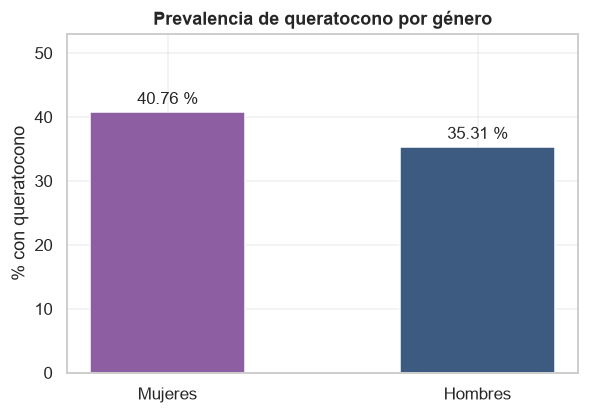

Diferencia (mujeres - hombres): +5.45 puntos porcentuales


In [ ]:
# Prevalencia de queratocono dentro de cada género
prev = pd.crosstab(df["gender"], df["label"], margins=True)
prev.columns = ["Normal (0)", "Queratocono (1)", "Total"]
prev["% con queratocono"] = (100 * prev["Queratocono (1)"] / prev["Total"]).round(2)
display(prev)

fig, ax = plt.subplots(figsize=(6, 4))
p = prev.loc[["f", "m"], "% con queratocono"]
b = ax.bar(["Mujeres", "Hombres"], p.values, color=["#8E5EA2", "#3D5A80"], width=0.5)
ax.bar_label(b, labels=[f"{v:.2f} %" for v in p.values], padding=3, fontsize=11)
ax.set_ylabel("% con queratocono")
ax.set_ylim(0, max(p) * 1.3)
ax.set_title("Prevalencia de queratocono por género", fontweight="bold")
plt.show()

print(f"Diferencia (mujeres - hombres): {p.iloc[0] - p.iloc[1]:+.2f} puntos porcentuales")


In [ ]:
# Chi-cuadrado + odds ratio (scipy)
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["gender"], df["label"])
chi2, p_valor, gl, esperados = chi2_contingency(ct)

a, b_, c, d = ct.loc["f", 1], ct.loc["f", 0], ct.loc["m", 1], ct.loc["m", 0]
or_ratio = (a * d) / (b_ * c)
se = np.sqrt(1 / a + 1 / b_ + 1 / c + 1 / d)
ic_low, ic_high = np.exp(np.log(or_ratio) - 1.96 * se), np.exp(np.log(or_ratio) + 1.96 * se)

print(f"Chi-cuadrado = {chi2:.3f}  (gl = {gl})")
print(f"p-valor = {p_valor:.4f}")
print("\nValores esperados si género y etiqueta fueran independientes:")
display(pd.DataFrame(esperados, index=ct.index, columns=ct.columns).round(1))
print(f"Odds ratio (mujeres vs hombres): {or_ratio:.2f}  |  IC 95 %: [{ic_low:.2f}, {ic_high:.2f}]")
print("Significativo al 5 %:", "SÍ" if p_valor < 0.05 else "NO")


Chi-cuadrado = 3.909  (gl = 1)
p-valor = 0.0480

Valores esperados si género y etiqueta fueran independientes:


label,0,1
gender,,
f,579.00,368.00
m,310.00,197.00


Odds ratio (mujeres vs hombres): 1.26  |  IC 95 %: [1.01, 1.58]
Significativo al 5 %: SÍ


In [ ]:
# Mismo análisis a nivel de PACIENTE (una observación independiente por paciente)
por_paciente = df.groupby("patient_code").agg(gender=("gender", "first"), label=("label", "first"))

ct_p = pd.crosstab(por_paciente["gender"], por_paciente["label"])
chi2_p, p_p, gl_p, _ = chi2_contingency(ct_p)

a, b_, c, d = ct_p.loc["f", 1], ct_p.loc["f", 0], ct_p.loc["m", 1], ct_p.loc["m", 0]
or_p = (a * d) / (b_ * c)
se_p = np.sqrt(1 / a + 1 / b_ + 1 / c + 1 / d)

prev_p = (pd.crosstab(por_paciente["gender"], por_paciente["label"], normalize="index") * 100).round(2)
prev_p.columns = ["Normal (0)", "Queratocono (1)"]

print(f"Nivel PACIENTE (n = {len(por_paciente)}):")
display(ct_p)
display(prev_p)
print(f"Chi2 = {chi2_p:.3f}, p = {p_p:.4f} -> {'significativo' if p_p < 0.05 else 'NO significativo'} al 5 %")
print(f"Odds ratio: {or_p:.2f}  |  IC 95 %: [{np.exp(np.log(or_p) - 1.96 * se_p):.2f}, {np.exp(np.log(or_p) + 1.96 * se_p):.2f}]")


Nivel PACIENTE (n = 744):


label,0,1
gender,,
f,282,194
m,164,104


,Normal (0),Queratocono (1)
gender,,
f,59.24,40.76
m,61.19,38.81


Chi2 = 0.196, p = 0.6576 -> NO significativo al 5 %
Odds ratio: 1.08  |  IC 95 %: [0.80, 1.47]


**Interpretación**

| Nivel | Prevalencia mujeres | Prevalencia hombres | Chi2 | p | OR (IC 95 %) |
|---|---|---|---|---|---|
| Ojo (1,454) | 40.76 % | 35.31 % | 3.91 | **0.048** | 1.26 [1.01, 1.58] |
| Paciente (744) | 40.76 % | 38.81 % | 0.20 | 0.658 | 1.08 [0.80, 1.47] |

*Nota: `scipy.stats.chi2_contingency` aplica por defecto la corrección de continuidad de Yates en tablas 2×2, por eso χ² = 3.91 (sin corregir sería 4.14, p = 0.042); la conclusión no cambia.*

- **A nivel de ojo** parece que las mujeres tienen más probabilidad (+5.45 pp, p = 0.048), pero la diferencia **no se sostiene a nivel de paciente** (p = 0.658): el resultado "significativo" era en parte un artefacto de contar ambos ojos de un mismo paciente como observaciones independientes.
- Conclusión: **no hay evidencia robusta de que un género tenga más probabilidad de queratocono en este dataset.**

**¿Para qué sirve esto en el proyecto?**

1. **Fairness / sesgo**: aunque la diferencia no sea significativa, el género sí está desbalanceado (65 % mujeres) y correlaciona levemente con la etiqueta; un modelo puede usarlo como atajo. Reporta métricas (accuracy, F1, sensibilidad) **desagregadas por género**.
2. **Estratificación**: al re-muestrear o re-partir, considera estratificar por `label × gender` para conservar estas proporciones en train/test.
3. **Confundidor**: el género también se asocia a variables clínicas (edad), así que conviene verificarlo al interpretar correlaciones.
4. **Límite del dataset**: estas probabilidades son *dentro de la muestra clínica*, no de la población general; el dataset excluyó casos dudosos/borde según su documentación.


## 8. Conclusiones

**Composición del dataset (1,454 registros / 744 pacientes)**

| Dimensión | Distribución |
|---|---|
| `label` (0 = normal, 1 = queratocono) | **0: 889 = 61.14 %** · **1 (queratocono): 565 = 38.86 %** → desbalance ≈ 1.57 : 1 |
| `split_80_20` | **train: 1,163 = 79.99 %** · **test: 291 = 20.01 %** |
| `fold` | 5 folds solo en train (≈ 20 % cada uno: 230–236 registros); el test no tiene fold |
| `gender` | femenino: 947 = 65.13 % · masculino: 507 = 34.87 % · prevalencia de queratocono: mujeres 40.76 % vs hombres 35.31 % (ojo) / 38.81 % (paciente) |
| `eye` | OD: 730 = 50.21 % · OS: 724 = 49.79 % (prácticamente balanceado) |
| Pacientes | 446 normales (59.95 %) · 298 con queratocono (40.05 %) |

**Cómo está clasificado el dataset**
1. **Etiqueta binaria** `label` ∈ {0, 1}: la columna a predecir.
2. **Partición estratificada 80/20** (`split_80_20`): la proporción de clases se conserva en train (61.14 % / 38.86 %) y en test (61.17 % / 38.83 %).
3. **5 folds** (`fold`) únicamente sobre train para validación cruzada; el test queda intacto para la evaluación final.
4. **Sin fugas**: ningún paciente aparece en train y en test simultáneamente y la etiqueta es constante por paciente.

**Calidad de los datos**
- Sin nulos en las 16 columnas clínicas; los 291 valores vacíos de `fold` son esperables (son las filas de test).
- Sin filas duplicadas exactas. Existen 46 pares paciente-ojo con mediciones repetidas (47 filas extra): son mediciones distintas, no duplicados, conviene definir si se agregan o se trata como muestras independientes.
- Sin desbalances extremos de género u ojo; la clase positiva es la minoritaria (38.9 %).
- En el inventario de imágenes hay un desajuste de nombres: el CSV usa `3E+132` y la carpeta se llama `3E132` (ambos ojos), así que 2 filas no encuentran su carpeta y 2 carpetas no tienen fila; hay que homologarlos antes de entrenar.

**Señal clínica esperada (guía para el modelado)**
- Ranking por |r| con la etiqueta: **kmax_value_D (0.69) > pachy_thinnest_um (−0.67) > astig_value_D (−0.66) > asphericity_anterior (−0.64) > asphericity_posterior (−0.62) > pachy_central_um (−0.56)**; `pachy_thinnest_x/y` y las edades aportan poco linealmente.
- `pachy_thinnest_um` / `pachy_central_um` menores y `asphericity_*` más negativos en queratocono.
- Por colinealidad clínica, usar regularización (L1/L2) o selección de características; las variables angulares deben codificarse con `sin`/`cos`.
- **Género**: la mayor prevalencia en mujeres a nivel ojo (p = 0.048) desaparece a nivel paciente (p = 0.658) → no hay sesgo de clase fuerte por género, pero reporta métricas desagregadas y estratifica `label × gender` si re-muestras.
